In [3]:
# ============================================
# EEG Modelling — Cell 1
# Setup + loading + subject-wise split + dataloaders
# ============================================

import os
import random
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, cohen_kappa_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------------------
# Reproducibility
# -------------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# -------------------------------
# Device
# -------------------------------
# -------------------------------
# Device
# -------------------------------
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print("Detected GPU:", gpu_name)
    device = torch.device("cuda")
else:
    gpu_name = "CPU"
    print("Detected GPU: CPU")
    device = torch.device("cpu")

PIN_MEMORY = (device.type == "cuda")
print("Using device:", device)
# -------------------------------
# Paths
# -------------------------------
DATA_DIR = Path("/kaggle/input/datasets/katakuricharlotte/eeg-preprocessing-and-epoching-results/eeg_preproc_outputs")
OUT_DIR = Path("/kaggle/working/eeg_model_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

X = np.load(DATA_DIR / "X.npy")          # [N, T, C]
y = np.load(DATA_DIR / "y.npy")          # [N]
subjects = np.load(DATA_DIR / "subjects.npy")
meta_df = pd.read_csv(DATA_DIR / "meta.csv")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)
print("Unique subjects:", np.unique(subjects))
print("Class counts:", pd.Series(y).value_counts().sort_index().to_dict())

# -------------------------------
# Subject-wise split
# -------------------------------
# Fixed split for first experiment:
# Train = A01-A06, Val = A07-A08, Test = A09
train_subjects = ["A01", "A02", "A03", "A04", "A05", "A06"]
val_subjects   = ["A07", "A08"]
test_subjects  = ["A09"]

train_mask = np.isin(subjects, train_subjects)
val_mask   = np.isin(subjects, val_subjects)
test_mask  = np.isin(subjects, test_subjects)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val     = X[val_mask], y[val_mask]
X_test, y_test   = X[test_mask], y[test_mask]

print("\nSplit sizes:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

# -------------------------------
# Dataset class
# -------------------------------
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)   # [N, T, C]
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_ds = EEGDataset(X_train, y_train)
val_ds   = EEGDataset(X_val, y_val)
test_ds  = EEGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

# -------------------------------
# Plot style helper
# -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
})

def paper_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle=":", linewidth=0.8, alpha=0.85)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(which="both", direction="in", top=True, right=True)

CLASS_NAMES = ["left_hand", "right_hand", "feet", "tongue"]

Detected GPU: Tesla T4
Using device: cuda
X shape: (2592, 1000, 22)
y shape: (2592,)
subjects shape: (2592,)
Unique subjects: ['A01' 'A02' 'A03' 'A04' 'A05' 'A06' 'A07' 'A08' 'A09']
Class counts: {0: 648, 1: 648, 2: 648, 3: 648}

Split sizes:
Train: (1728, 1000, 22) (1728,)
Val  : (576, 1000, 22) (576,)
Test : (288, 1000, 22) (288,)


Class weights: [1. 1. 1. 1.]
[eegnet_bilstm] epoch=01 lr=0.001000 train_loss=1.4362 train_f1=0.2523 val_loss=1.3902 val_f1=0.1000
[eegnet_bilstm] epoch=02 lr=0.001000 train_loss=1.4060 train_f1=0.2471 val_loss=1.3845 val_f1=0.1781
[eegnet_bilstm] epoch=03 lr=0.001000 train_loss=1.3952 train_f1=0.2598 val_loss=1.3987 val_f1=0.1038
[eegnet_bilstm] epoch=04 lr=0.001000 train_loss=1.4074 train_f1=0.2612 val_loss=1.3805 val_f1=0.1925
[eegnet_bilstm] epoch=05 lr=0.001000 train_loss=1.3828 train_f1=0.2839 val_loss=1.3558 val_f1=0.2415
[eegnet_bilstm] epoch=06 lr=0.001000 train_loss=1.3755 train_f1=0.2877 val_loss=1.3464 val_f1=0.2710
[eegnet_bilstm] epoch=07 lr=0.001000 train_loss=1.3505 train_f1=0.3287 val_loss=1.3361 val_f1=0.2983
[eegnet_bilstm] epoch=08 lr=0.001000 train_loss=1.3370 train_f1=0.3380 val_loss=1.4427 val_f1=0.1845
[eegnet_bilstm] epoch=09 lr=0.001000 train_loss=1.3305 train_f1=0.3433 val_loss=1.3240 val_f1=0.2957
[eegnet_bilstm] epoch=10 lr=0.001000 train_loss=1.3145 train_f

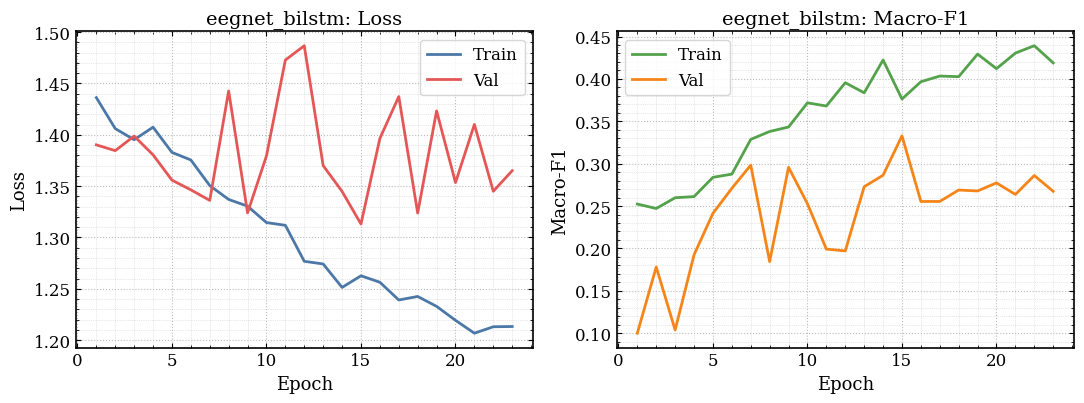

Saved: /kaggle/working/eeg_model_outputs/curve_eegnet_bilstm.png


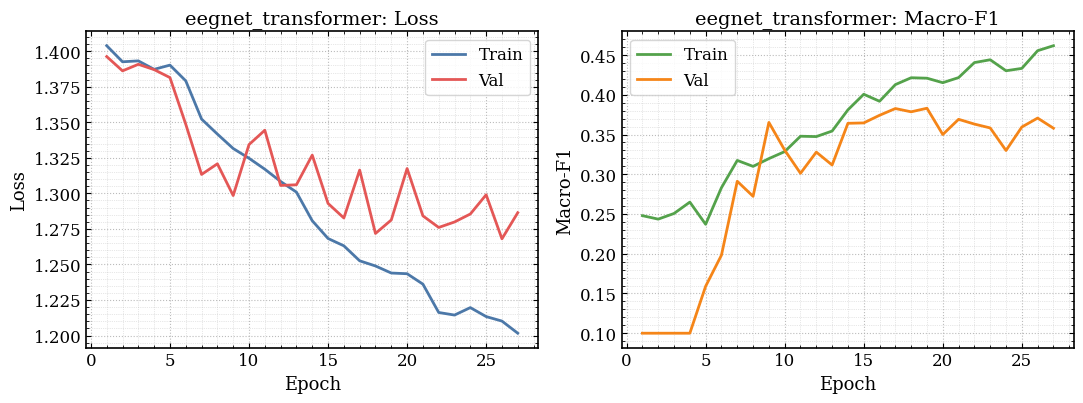

Saved: /kaggle/working/eeg_model_outputs/curve_eegnet_transformer.png


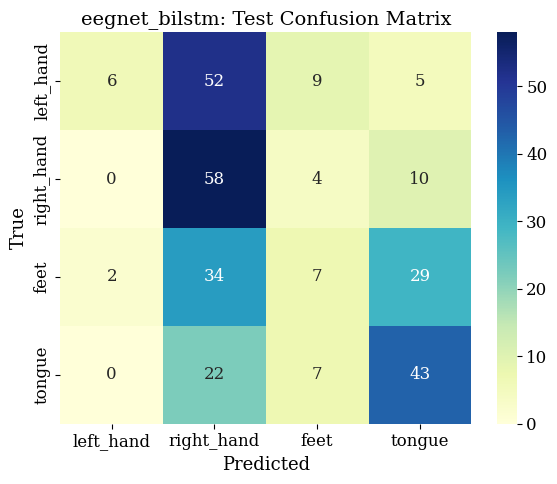

Saved: /kaggle/working/eeg_model_outputs/cm_eegnet_bilstm.png


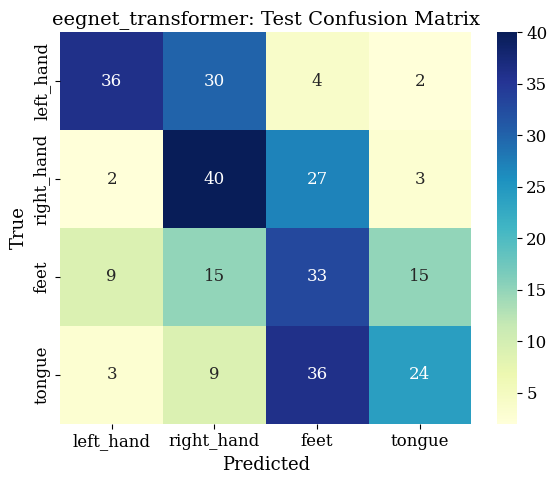

Saved: /kaggle/working/eeg_model_outputs/cm_eegnet_transformer.png

Final test results:


,model,best_epoch,best_val_macro_f1,test_acc,test_macro_f1,test_kappa,best_ckpt
0,EEGNet-BiLSTM,15,0.332852,0.395833,0.329922,0.194444,/kaggle/working/eeg_model_outputs/best_eegnet_...
1,EEGNet-Transformer,19,0.383054,0.461806,0.467401,0.282407,/kaggle/working/eeg_model_outputs/best_eegnet_...



EEGNet-BiLSTM classification report:
              precision    recall  f1-score   support

   left_hand     0.7500    0.0833    0.1500        72
  right_hand     0.3494    0.8056    0.4874        72
        feet     0.2593    0.0972    0.1414        72
      tongue     0.4943    0.5972    0.5409        72

    accuracy                         0.3958       288
   macro avg     0.4632    0.3958    0.3299       288
weighted avg     0.4632    0.3958    0.3299       288


EEGNet-Transformer classification report:
              precision    recall  f1-score   support

   left_hand     0.7200    0.5000    0.5902        72
  right_hand     0.4255    0.5556    0.4819        72
        feet     0.3300    0.4583    0.3837        72
      tongue     0.5455    0.3333    0.4138        72

    accuracy                         0.4618       288
   macro avg     0.5052    0.4618    0.4674       288
weighted avg     0.5052    0.4618    0.4674       288

Saved: /kaggle/working/eeg_model_outputs/model_re

In [4]:
# ============================================
# EEG Modelling — Improved Cell 2
# EEGNet-BiLSTM vs EEGNet-Transformer
# ============================================

import copy
from sklearn.utils.class_weight import compute_class_weight

# -------------------------------
# Class weights from training split
# -------------------------------
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Class weights:", class_weights.detach().cpu().numpy())

# -------------------------------
# EEGNet-style feature extractor
# input: [B, T, C]
# internally uses [B, 1, C, T]
# -------------------------------
class EEGNetBackbone(nn.Module):
    def __init__(self, n_channels=22, dropout=0.25, F1=8, D=2, F2=16, kernel_length=64):
        super().__init__()
        self.n_channels = n_channels

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kernel_length), padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1),

            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )

        self.out_features = F2

    def forward(self, x):
        # x: [B, T, C]
        x = x.permute(0, 2, 1)          # [B, C, T]
        x = x.unsqueeze(1)              # [B, 1, C, T]
        x = self.block1(x)              # [B, F1*D, 1, T1]
        x = self.block2(x)              # [B, F2, 1, T2]
        x = x.squeeze(2)                # [B, F2, T2]
        x = x.permute(0, 2, 1)          # [B, T2, F2]
        return x

# -------------------------------
# Safe LSTM
# -------------------------------
class SafeLSTM(nn.LSTM):
    def flatten_parameters(self):
        return

# -------------------------------
# Model 1: EEGNet + BiLSTM
# -------------------------------
class EEGNetBiLSTM(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, dropout=0.3):
        super().__init__()
        self.backbone = EEGNetBackbone(n_channels=n_channels, dropout=dropout, F1=8, D=2, F2=32, kernel_length=64)
        self.lstm = SafeLSTM(
            input_size=32,
            hidden_size=96,
            num_layers=2,
            batch_first=True,
            dropout=0.25,
            bidirectional=True
        )
        self.head = nn.Sequential(
            nn.LayerNorm(192),
            nn.Dropout(dropout),
            nn.Linear(192, 96),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(96, n_classes)
        )

    def forward(self, x):
        x = self.backbone(x)            # [B, T', 32]
        x, _ = self.lstm(x)             # [B, T', 192]
        x = x.mean(dim=1)               # temporal mean pooling
        x = self.head(x)
        return x

# -------------------------------
# Positional Encoding
# -------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# -------------------------------
# Model 2: EEGNet + Transformer
# -------------------------------
class EEGNetTransformer(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, d_model=64, nhead=4, num_layers=3, ff_mult=4, dropout=0.25):
        super().__init__()
        self.backbone = EEGNetBackbone(n_channels=n_channels, dropout=dropout, F1=8, D=2, F2=32, kernel_length=64)
        self.proj = nn.Linear(32, d_model)
        self.pos = PositionalEncoding(d_model=d_model, max_len=512)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * ff_mult,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.backbone(x)            # [B, T', 32]
        x = self.proj(x)                # [B, T', d_model]
        x = self.pos(x)
        x = self.encoder(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        x = self.head(x)
        return x

# -------------------------------
# Train / eval helpers
# -------------------------------
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    n_batches = 0
    all_true, all_pred = [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item()
        n_batches += 1
        all_true.extend(yb.detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    return {
        "loss": total_loss / max(n_batches, 1),
        "acc": accuracy_score(all_true, all_pred),
        "f1": f1_score(all_true, all_pred, average="macro"),
        "kappa": cohen_kappa_score(all_true, all_pred),
        "y_true": all_true,
        "y_pred": all_pred
    }

def train_model(model, train_loader, val_loader, model_name, epochs=40, lr=1e-3, patience=8):
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_state = None
    best_f1 = -1.0
    best_epoch = -1
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        va = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(va["f1"])
        lr_now = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "lr": lr_now,
            "train_loss": tr["loss"],
            "train_acc": tr["acc"],
            "train_f1": tr["f1"],
            "train_kappa": tr["kappa"],
            "val_loss": va["loss"],
            "val_acc": va["acc"],
            "val_f1": va["f1"],
            "val_kappa": va["kappa"],
        })

        print(
            f"[{model_name}] epoch={epoch:02d} "
            f"lr={lr_now:.6f} "
            f"train_loss={tr['loss']:.4f} train_f1={tr['f1']:.4f} "
            f"val_loss={va['loss']:.4f} val_f1={va['f1']:.4f}"
        )

        if va["f1"] > best_f1:
            best_f1 = va["f1"]
            best_epoch = epoch
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1

        if wait >= patience:
            print(f"[{model_name}] Early stopping at epoch {epoch} (best epoch {best_epoch}, best val_f1 {best_f1:.4f})")
            break

    model.load_state_dict(best_state)

    ckpt_path = OUT_DIR / f"best_{model_name}.pt"
    torch.save(best_state, ckpt_path)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUT_DIR / f"history_{model_name}.csv", index=False)

    test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)

    return hist_df, test_metrics, ckpt_path, best_epoch, best_f1

def save_training_curves(hist_df, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train", color="#4C78A8", linewidth=2)
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val", color="#E45756", linewidth=2)
    axes[0].set_title(f"{model_name}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    paper_axes(axes[0])

    axes[1].plot(hist_df["epoch"], hist_df["train_f1"], label="Train", color="#54A24B", linewidth=2)
    axes[1].plot(hist_df["epoch"], hist_df["val_f1"], label="Val", color="#F58518", linewidth=2)
    axes[1].set_title(f"{model_name}: Macro-F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro-F1")
    axes[1].legend()
    paper_axes(axes[1])

    fig.tight_layout()
    out = OUT_DIR / f"curve_{model_name}.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

def save_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="YlGnBu",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
    )
    ax.set_title(f"{model_name}: Test Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    fig.tight_layout()
    out = OUT_DIR / f"cm_{model_name}.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

# -------------------------------
# Train improved models
# -------------------------------
eegnet_bilstm = EEGNetBiLSTM(n_channels=22, n_classes=4, dropout=0.30).to(device)
eegnet_transformer = EEGNetTransformer(
    n_channels=22, n_classes=4, d_model=64, nhead=4, num_layers=3, ff_mult=4, dropout=0.25
).to(device)

hist_bilstm, test_bilstm, ckpt_bilstm, best_epoch_bilstm, best_f1_bilstm = train_model(
    eegnet_bilstm, train_loader, val_loader, model_name="eegnet_bilstm", epochs=40, lr=1e-3, patience=8
)

hist_trf, test_trf, ckpt_trf, best_epoch_trf, best_f1_trf = train_model(
    eegnet_transformer, train_loader, val_loader, model_name="eegnet_transformer", epochs=40, lr=8e-4, patience=8
)

# -------------------------------
# Save plots
# -------------------------------
save_training_curves(hist_bilstm, "eegnet_bilstm")
save_training_curves(hist_trf, "eegnet_transformer")

save_confusion(test_bilstm["y_true"], test_bilstm["y_pred"], "eegnet_bilstm")
save_confusion(test_trf["y_true"], test_trf["y_pred"], "eegnet_transformer")

# -------------------------------
# Final comparison table
# -------------------------------
results_df = pd.DataFrame([
    {
        "model": "EEGNet-BiLSTM",
        "best_epoch": best_epoch_bilstm,
        "best_val_macro_f1": best_f1_bilstm,
        "test_acc": test_bilstm["acc"],
        "test_macro_f1": test_bilstm["f1"],
        "test_kappa": test_bilstm["kappa"],
        "best_ckpt": str(ckpt_bilstm)
    },
    {
        "model": "EEGNet-Transformer",
        "best_epoch": best_epoch_trf,
        "best_val_macro_f1": best_f1_trf,
        "test_acc": test_trf["acc"],
        "test_macro_f1": test_trf["f1"],
        "test_kappa": test_trf["kappa"],
        "best_ckpt": str(ckpt_trf)
    }
])

results_csv = OUT_DIR / "model_results_improved.csv"
results_df.to_csv(results_csv, index=False)

print("\nFinal test results:")
display(results_df)

print("\nEEGNet-BiLSTM classification report:")
print(classification_report(test_bilstm["y_true"], test_bilstm["y_pred"], target_names=CLASS_NAMES, digits=4))

print("\nEEGNet-Transformer classification report:")
print(classification_report(test_trf["y_true"], test_trf["y_pred"], target_names=CLASS_NAMES, digits=4))

print("Saved:", results_csv)